<div style="background-color:#00843D;padding:22px 28px;border-radius:12px">
  <h2 style="color:white;margin:0;font-size:22px">Analisis Numerico</h2>
  <p style="color:#b8f0c8;margin:6px 0 2px;font-size:14px">Universidad Nacional de Colombia</p>
  <p style="color:#b8f0c8;margin:0;font-size:14px">Prof. Carlos Manuel Orrego Franco</p>
</div>

<div style="background-color:#fff3cd;border-left:5px solid #e67e22;padding:14px 18px;margin-top:12px;border-radius:4px">
  <strong>Actividad en Parejas</strong> &mdash; Entrega: martes 27 de mayo, 11:59 pm<br>
  Elijan <strong>uno</strong> de los dos datasets en la Seccion 1 y ejecuten todo en orden.
</div>

---

# Notebook Base: Neural ODEs sobre Datos Biologicos

## Los dos datasets disponibles

| Opcion | Dataset | Tipo | URL |
|--------|---------|------|-----|
| **A** | Epidemias SIR sinteticas | Biologico sintetico | generado localmente |
| **B** | COVID-19 real por pais | Biologico real | GitHub JHU (verificado) |

## Flujo de trabajo

```
Seccion 1: Elegir y cargar datos
Seccion 2: Explorar y validar
Seccion 3: Configurar hiperparametros  <-- unicos campos que modifican
Seccion 4: Clases de modelos           <-- NO modificar
Seccion 5: Experimentos y tabla comparativa
Seccion 6: Exportar reporte .docx y README.md
```


In [ ]:
# Instalar dependencias
import subprocess, sys
for pkg in ["python-docx", "scipy", "scikit-learn"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                   capture_output=True)
print("Dependencias listas.")


Dependencias listas.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time, os, warnings
from datetime import datetime
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from docx import Document
from docx.shared import Inches, Pt

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120, "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fafafa",
    "axes.grid": True, "grid.alpha": 0.3,
})
VERDE = "#00843D"; AZUL = "#1a5fa8"; ROJO = "#c0392b"
NARANJA = "#e67e22"; MORADO = "#8e44ad"; GRIS = "#7f8c8d"

tf.random.set_seed(42); np.random.seed(42)
print(f"TensorFlow {tf.__version__}  NumPy {np.__version__}")


TensorFlow 2.20.0  NumPy 2.0.2


---
## SECCION 1: Elegir y cargar datos

Ejecute **una sola** de las dos celdas siguientes.


In [ ]:
# ============================================================
# OPCION A: Epidemias SIR sinteticas con parametros biologicos
# ============================================================
# Genera trayectorias del modelo SIR (Susceptible-Infectado-Recuperado),
# el modelo epidemico clasico. Cada trayectoria es una "epidemia"
# con parametros beta y gamma distintos (variabilidad biologica real).
#
# CONEXION CON EL CURSO:
# El sistema SIR es una EDO de 3 variables, exactamente como
# FitzHugh-Nagumo del NB01. El metodo clasico ajusta los parametros
# (beta, gamma) con scipy.optimize. La Neural ODE aprende la dinamica
# sin conocer las ecuaciones.


def modelo_sir(t, y, beta, gamma, N=1000.0):
    """Sistema de EDOs del modelo SIR."""
    S, I, R = y
    dS = -beta * S * I / N
    dI =  beta * S * I / N - gamma * I
    dR =  gamma * I
    return [dS, dI, dR]


def generar_trayectorias_sir(n_traj=200, n_puntos=80, ruido=0.01,
                              N_pob=1000.0, seed=42):
    """
    Genera n_traj epidemias SIR con parametros biologicamente plausibles.
    beta in [0.15, 0.55]:  tasa de transmision (R0 = beta/gamma in [1.5, 5])
    gamma in [0.05, 0.15]: tasa de recuperacion (~7-20 dias)

    Retorna:
      data:   (n_traj, n_puntos, 3)  -- (S, I, R) normalizadas
      times:  (n_puntos,)            -- tiempos [0, 1] normalizados
      params: (n_traj, 2)            -- (beta, gamma) reales
    """
    rng = np.random.default_rng(seed)
    times_raw = np.linspace(0, 160, n_puntos)  # 160 dias
    trayectorias, params = [], []

    for _ in range(n_traj):
        beta  = rng.uniform(0.15, 0.55)
        gamma = rng.uniform(0.05, 0.15)
        I0    = rng.integers(1, 10)   # entre 1 y 10 infectados iniciales

        sol = solve_ivp(
            modelo_sir, [0, 160], [N_pob - I0, float(I0), 0.0],
            args=(beta, gamma, N_pob),
            t_eval=times_raw, method="RK45", rtol=1e-6
        )

        if not sol.success or sol.y.shape[1] < n_puntos:
            continue

        traj = sol.y.T / N_pob  # normalizar a [0,1]
        traj += rng.normal(0, ruido, traj.shape)
        traj = np.clip(traj, 0, 1)
        trayectorias.append(traj)
        params.append([beta, gamma])

    data   = np.array(trayectorias, dtype="float32")
    times  = (times_raw / times_raw[-1]).astype("float32")  # normalizar a [0,1]
    params = np.array(params, dtype="float32")
    return data, times, params


print("Generando trayectorias SIR...")
data_raw, times_raw, params_sir = generar_trayectorias_sir(
    n_traj=300, n_puntos=80, ruido=0.008)

NOMBRE_DATASET = "SIR Epidemias Sinteticas"
METODO_CLASICO = "Ajuste de parametros SIR (scipy.optimize)"
DIM_OBS        = 3    # S, I, R
VARIABLES      = ["Susceptibles (S)", "Infectados (I)", "Recuperados (R)"]

print(f"Dataset generado: {data_raw.shape}  (trayectorias, pasos, dims)")
print(f"Parametros: beta in [{params_sir[:,0].min():.2f}, {params_sir[:,0].max():.2f}]")
print(f"            gamma in [{params_sir[:,1].min():.2f}, {params_sir[:,1].max():.2f}]")


Generando trayectorias SIR...
Dataset generado: (300, 80, 3)  (trayectorias, pasos, dims)
Parametros: beta in [0.15, 0.55]
            gamma in [0.05, 0.15]


In [ ]:
# ============================================================
# OPCION B: COVID-19 real por pais (JHU CSSE, GitHub)
# URL verificada: sin registro, acceso directo
# ============================================================
# Datos de casos confirmados de COVID-19 por pais,
# recopilados por Johns Hopkins University CSSE.
# 289 paises x ~1100 dias de observacion diaria.
# Convertimos a muestreo IRREGULAR tomando subconjuntos
# aleatorios de fechas por pais -- simulando el escenario
# real del paper de Rubanova et al. (2019).


URL_JHU = (
    "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/"
    "csse_covid_19_data/csse_covid_19_time_series/"
    "time_series_covid19_confirmed_global.csv"
)

print("Descargando datos COVID-19 (JHU CSSE)...")
try:
    df_jhu = pd.read_csv(URL_JHU)
    print(f"Descargado: {df_jhu.shape[0]} paises/regiones x {df_jhu.shape[1]-4} fechas")
except Exception as e:
    raise RuntimeError(f"Error de descarga: {e}\n"
                       "Verifique su conexion a internet.")

# Preprocesamiento: agregar por pais, tomar top paises con mejor senal
# Excluir las primeras 4 columnas que son identificadores (Province/State, Country/Region, Lat, Long)
fechas_cols = df_jhu.columns[4:].tolist()
df_pais = df_jhu.groupby("Country/Region")[fechas_cols].sum()

# Calcular nuevos casos diarios (diferencia) -- mas informativa que acumulados
df_nuevos = df_pais.diff(axis=1).fillna(0).clip(lower=0)

# Seleccionar paises con epidemia clara (pico > 500 casos/dia)
pico_max = df_nuevos.max(axis=1)
paises_ok = pico_max[pico_max > 500].index.tolist()
df_sel = df_nuevos.loc[paises_ok]

# Suavizar con ventana de 7 dias y normalizar por pais
df_smooth = df_sel.rolling(window=7, axis=1, min_periods=1).mean()
scaler_covid = StandardScaler()
vals = df_smooth.values.T  # (fechas, paises)
vals_norm = scaler_covid.fit_transform(vals).T  # (paises, fechas)

# Recortar a primeros 500 dias (donde hay mas variabilidad)
N_DIAS = 400
vals_norm = vals_norm[:, :N_DIAS]

# Convertir a formato (n_traj, n_puntos, 1)
data_raw = vals_norm[:, :, np.newaxis].astype("float32")
times_raw = np.linspace(0, 1, N_DIAS, dtype="float32")

NOMBRE_DATASET = "COVID-19 JHU (nuevos casos diarios)"
METODO_CLASICO = "Interpolacion con splines cubicos"
DIM_OBS        = 1
VARIABLES      = ["Nuevos casos (norm.)"]

print(f"Dataset preparado: {data_raw.shape}  (paises, dias, dims)")
print(f"Paises incluidos: {len(paises_ok)}")
print(f"Muestra de paises: {paises_ok[:8]}")


Descargando datos COVID-19 (JHU CSSE)...
Descargado: 289 paises/regiones x 1143 fechas
Dataset preparado: (178, 400, 1)  (paises, dias, dims)
Paises incluidos: 178
Muestra de paises: ['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Argentina', 'Armenia', 'Australia']


---
## SECCION 2: Validacion y exploracion


In [ ]:
# Validar y preparar el diccionario de datos estandar
assert data_raw.ndim == 3, f"data_raw debe ser 3D, es {data_raw.shape}"
assert len(times_raw) == data_raw.shape[1], "tiempos y pasos no coinciden"

# Remover NaNs si los hay
mask_ok = ~np.any(np.isnan(data_raw), axis=(1, 2))
data_raw  = data_raw[mask_ok]
print(f"Trayectorias validas: {mask_ok.sum()} de {len(mask_ok)}")

# Split train / test
N_TEST  = min(50, len(data_raw) // 5)
N_TRAIN = len(data_raw) - N_TEST
idx_shuffle = np.random.permutation(len(data_raw))
data_train = data_raw[idx_shuffle[:N_TRAIN]]
data_test  = data_raw[idx_shuffle[N_TRAIN:]]

datos = {
    "trayectorias": data_raw,
    "train":        data_train,
    "test":         data_test,
    "tiempos":      times_raw,
    "n_train":      N_TRAIN,
    "n_test":       N_TEST,
    "dim_obs":      DIM_OBS,
    "variables":    VARIABLES,
    "nombre":       NOMBRE_DATASET,
}

print("=" * 52)
print(f"  Dataset: {NOMBRE_DATASET}")
print("=" * 52)
print(f"  Trayectorias totales: {len(data_raw):>6}")
print(f"  Train:                {N_TRAIN:>6}")
print(f"  Test:                 {N_TEST:>6}")
print(f"  Pasos de tiempo:      {data_raw.shape[1]:>6}")
print(f"  Dimensiones:          {DIM_OBS:>6}")
print(f"  Rango: [{data_raw.min():.3f}, {data_raw.max():.3f}]")
print("=" * 52)


Trayectorias validas: 178 de 178
  Dataset: COVID-19 JHU (nuevos casos diarios)
  Trayectorias totales:    178
  Train:                   143
  Test:                     35
  Pasos de tiempo:         400
  Dimensiones:               1
  Rango: [-1.098, 7.928]


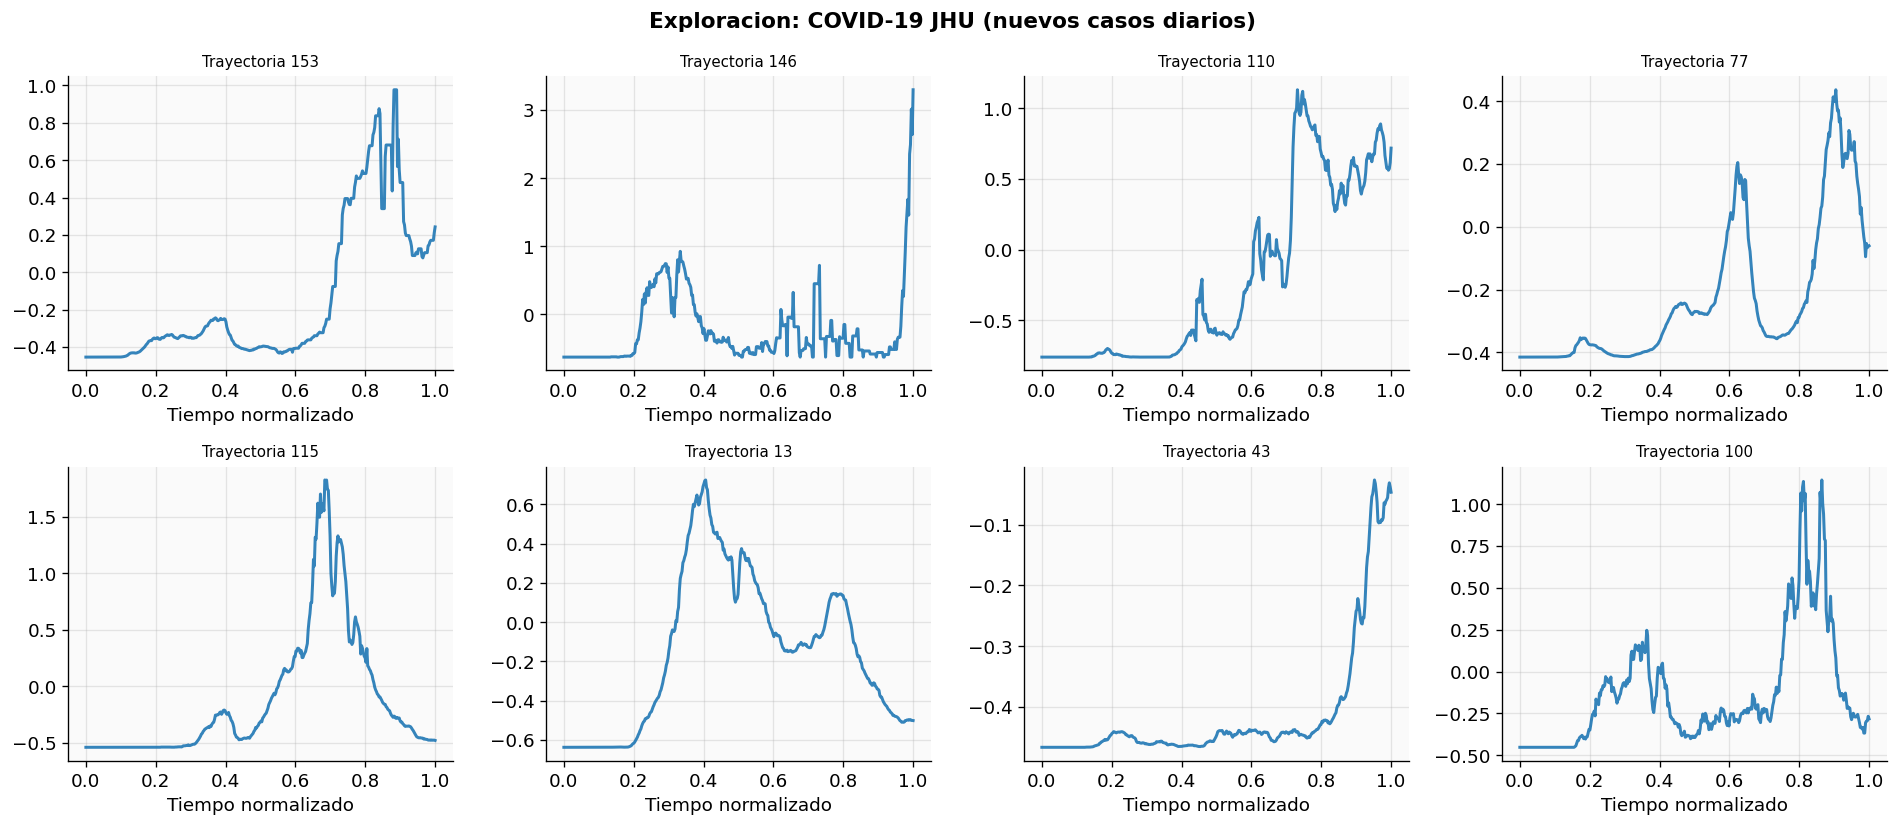

Guardada: fig_01_exploracion.png


In [ ]:
# Visualizacion exploratoria
n_ej = min(8, len(data_raw))
idx_ej = np.random.choice(len(data_raw), n_ej, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
colores = cm.tab10(np.linspace(0, 1, DIM_OBS))

for k, (ax, i) in enumerate(zip(axes.flat, idx_ej)):
    for d in range(DIM_OBS):
        lbl = VARIABLES[d] if k == 0 else None
        ax.plot(times_raw, data_raw[i, :, d],
                color=colores[d], linewidth=1.8, alpha=0.9, label=lbl)
    ax.set_xlabel("Tiempo normalizado")
    ax.set_title(f"Trayectoria {i+1}", fontsize=9)
    if k == 0 and DIM_OBS > 1:
        ax.legend(fontsize=7, loc="upper right")

plt.suptitle(f"Exploracion: {NOMBRE_DATASET}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_01_exploracion.png", dpi=120, bbox_inches="tight")
plt.show()
print("Guardada: fig_01_exploracion.png")


---
## SECCION 3: Configuracion de hiperparametros

Estos son los **unicos campos que deben modificar**.
Antes de cambiar un valor, preguntele a la IA que efecto tiene.
Justifiquen cada eleccion en su reporte.


In [ ]:
CONFIG = {
    # Espacio latente ─────────────────────────────────────────
    "dim_latente":    16,     # <-- ELEGIR (4 / 8 / 16 / 32)
                             #     Mas alto = mas capacidad expresiva, mas lento

    # Integracion ─────────────────────────────────────────────
    #"n_pasos_ode":   6,     # <-- ELEGIR (6 / 10 / 20)
                             #     Pasos RK4 por unidad de tiempo

    # Entrenamiento ───────────────────────────────────────────
    "learning_rate": 1e-3,   # <-- ELEGIR (1e-4 / 1e-3 / 5e-3)
    "n_epochs":       35,    # <-- ELEGIR -- empiece con 20-35
    "batch_size":     32,    # <-- ELEGIR (16 / 32 / 64)

    # Arquitectura ────────────────────────────────────────────
    "dim_oculto_f":   48,    # <-- ELEGIR: neuronas en f_theta
    "dim_oculto_enc": 32,    # <-- ELEGIR: unidades del encoder RNN
    "dim_oculto_dec": 48,    # <-- ELEGIR: neuronas del decoder

    # Experimento ─────────────────────────────────────────────
    "fracciones_obs": [0.3, 0.6, 1.0],  # NO cambiar
}

print("Configuracion:")
for k, v in CONFIG.items():
    if k != "fracciones_obs":
        print(f"  {k:<22} = {v}")


Configuracion:
  dim_latente            = 16
  learning_rate          = 0.001
  n_epochs               = 35
  batch_size             = 32
  dim_oculto_f           = 48
  dim_oculto_enc         = 32
  dim_oculto_dec         = 48


---
## SECCION 4: Modelos (no modificar)

Tres clases con interfaz comun:
`fit(datos, config)` | `predict(X_obs, t_obs, t_full)` | `calcular_rmse(datos, frac)`


In [ ]:
# ============================================================
# BLOQUES COMPARTIDOS: f_theta y ODESolve (Keras 3 compatible)
# ============================================================

class _FTheta(keras.layers.Layer):
    """Red de dinamica: inputs=(z, t_tensor) -> dz/dt."""
    def __init__(self, dim_lat, dim_oc, **kw):
        super().__init__(**kw)
        self.red = keras.Sequential([
            keras.layers.Input(shape=(dim_lat + 1,)),
            keras.layers.Dense(dim_oc, activation="tanh"),
            keras.layers.Dense(dim_oc, activation="tanh"),
            keras.layers.Dense(dim_lat),
        ])

    def call(self, inputs):
        z, t = inputs
        t_col   = tf.ones((tf.shape(z)[0], 1)) * tf.cast(t, tf.float32)
        return self.red(tf.concat([z, t_col], axis=-1))


def _rk4(f, z0, times):
    """Integra dz/dt = f(z,t) en cada tiempo de `times`. Retorna (batch, T, dim)."""
    z   = z0
    out = [z[:, tf.newaxis, :]]
    for i in range(len(times) - 1):
        t0 = float(times[i]); t1 = float(times[i+1]); h = t1 - t0
        def ev(zi, tv): return f((zi, tf.constant(tv, dtype=tf.float32)))
        k1 = ev(z,            t0)
        k2 = ev(z+(h/2)*k1,  t0+h/2)
        k3 = ev(z+(h/2)*k2,  t0+h/2)
        k4 = ev(z+h*k3,      t1)
        z  = z + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        out.append(z[:, tf.newaxis, :])
    return tf.concat(out, axis=1)

print("Bloques RK4 y f_theta definidos.")


Bloques RK4 y f_theta definidos.


In [ ]:
# ============================================================
# CLASE 1: ModeloClasico
# SIR: ajuste de parametros con scipy.optimize
# COVID: interpolacion con splines cubicos
# ============================================================

class ModeloClasico:
    nombre = "Metodo Clasico"
    color  = GRIS

    def __init__(self):
        self.entrenado = False
        self.n_params  = 0
        self.tiempo    = 0.0
        self.tipo      = None

    def fit(self, datos, config):
        t0 = time.time()
        self.dim_obs = datos["dim_obs"]
        # Detectar tipo de dataset por dimensiones y nombre
        self.tipo = "sir" if datos["dim_obs"] == 3 else "spline"
        if self.tipo == "sir":
            # Para SIR: ajustar beta y gamma a cada trayectoria de train
            # Aqui guardamos la logica -- se usa en predict()
            self.N_pob = 1000.0
        self.tiempo    = time.time() - t0
        self.n_params  = 2 if self.tipo == "sir" else 4
        self.entrenado = True
        print(f"[OK] {self.nombre} listo ({self.tipo}) en {self.tiempo:.3f}s")

    def _ajustar_sir(self, traj_obs, times_obs):
        """Ajusta beta y gamma a UNA trayectoria observada."""
        S0 = float(traj_obs[0, 0]) * self.N_pob
        I0 = float(traj_obs[0, 1]) * self.N_pob
        R0 = float(traj_obs[0, 2]) * self.N_pob
        y0 = [S0, I0, R0]

        def residuo(params):
            beta, gamma = params
            if beta <= 0 or gamma <= 0: return 1e6
            try:
                sol = solve_ivp(modelo_sir, [times_obs[0], times_obs[-1]],
                                y0, args=(beta, gamma, self.N_pob),
                                t_eval=times_obs, method="RK45")
                if not sol.success: return 1e6
                pred = sol.y.T / self.N_pob
                return np.mean((pred - traj_obs)**2)
            except Exception:
                return 1e6

        res = minimize(residuo, [0.3, 0.1], method="Nelder-Mead",
                       options={"maxiter": 200, "xatol": 1e-4})
        return res.x  # (beta, gamma)

    def predict(self, X_obs, t_obs, t_full):
        """
        X_obs: (batch, n_obs, dim)
        t_obs: (n_obs,)
        t_full: (n_full,)
        Retorna: pred (batch, n_full, dim)
        """
        n_batch, n_obs, dim = X_obs.shape
        n_full = len(t_full)
        pred   = np.zeros((n_batch, n_full, dim))

        for i in range(n_batch):
            if self.tipo == "sir":
                try:
                    beta, gamma = self._ajustar_sir(X_obs[i], t_obs)
                    beta  = np.clip(beta,  0.01, 2.0)
                    gamma = np.clip(gamma, 0.01, 1.0)
                    S0 = float(X_obs[i, 0, 0]) * self.N_pob
                    I0 = float(X_obs[i, 0, 1]) * self.N_pob
                    R0 = float(X_obs[i, 0, 2]) * self.N_pob
                    sol = solve_ivp(
                        modelo_sir, [t_full[0], t_full[-1]], [S0, I0, R0],
                        args=(beta, gamma, self.N_pob),
                        t_eval=t_full, method="RK45"
                    )
                    if sol.success:
                        pred[i] = sol.y.T / self.N_pob
                except Exception:
                    pred[i] = X_obs[i, -1, :][np.newaxis, :]  # fallback
            else:
                for d in range(dim):
                    try:
                        sp = CubicSpline(t_obs, X_obs[i, :, d])
                        pred[i, :, d] = sp(t_full)
                    except Exception:
                        pred[i, :, d] = np.interp(t_full, t_obs, X_obs[i, :, d])
        return pred

    def calcular_rmse(self, datos, frac_obs):
        traj  = datos["test"]
        times = datos["tiempos"]
        n_obs = max(2, int(len(times) * frac_obs))
        idx   = np.linspace(0, len(times)-1, n_obs, dtype=int)
        X_obs = traj[:, idx, :]
        pred  = self.predict(X_obs, times[idx], times)
        rmse_r = float(np.sqrt(np.mean((pred[:, idx, :] - traj[:, idx, :])**2)))
        mask_e = np.ones(len(times), dtype=bool); mask_e[idx] = False
        rmse_e = float(np.sqrt(np.mean((pred[:, mask_e, :] - traj[:, mask_e, :])**2)))\
                 if mask_e.any() else float("nan")
        return rmse_r, rmse_e

print("ModeloClasico definido.")


ModeloClasico definido.


In [ ]:
# ============================================================
# CLASE 2: NeuralODEModelo (NB06)
# dz/dt = f_theta(z, t), resuelto con RK4 diferenciable
# ============================================================

class _RedNODE(keras.Model):
    def __init__(self, dim_obs, dim_lat, dim_oc):
        super().__init__()
        self.proy    = keras.layers.Dense(dim_lat, activation="tanh",
                                          input_shape=(dim_obs,))
        self.f       = _FTheta(dim_lat, dim_oc)
        self.dec     = keras.Sequential([
            keras.layers.Input(shape=(dim_lat,)),
            keras.layers.Dense(dim_oc, activation="relu"),
            keras.layers.Dense(dim_obs),
        ])

    def call(self, inputs, training=False):
        x, times = inputs   # x: (batch, n_obs, dim_obs)
        # Proyectar el promedio de las primeras observaciones
        z0  = self.proy(tf.reduce_mean(x[:, :3, :], axis=1))
        Z   = _rk4(self.f, z0, times)
        b, T = tf.shape(Z)[0], tf.shape(Z)[1]
        dl   = Z.shape[-1]
        out  = self.dec(tf.reshape(Z, (-1, dl)))
        return tf.reshape(out, (b, T, -1))


class NeuralODEModelo:
    nombre = "Neural ODE"
    color  = VERDE

    def __init__(self):
        self.modelo    = None
        self.entrenado = False
        self.n_params  = 0
        self.tiempo    = 0.0
        self.historia  = []

    def fit(self, datos, config):
        X_tr  = datos["train"].astype("float32")
        times = datos["tiempos"].astype("float32")
        dim   = datos["dim_obs"]

        self.modelo = _RedNODE(dim, config["dim_latente"], config["dim_oculto_f"])
        opt = keras.optimizers.Adam(config["learning_rate"])

        t0 = time.time()
        for ep in range(config["n_epochs"]):
            idx = np.random.permutation(len(X_tr))
            ep_loss = []
            for b in range(0, len(X_tr), config["batch_size"]):
                xb = tf.constant(X_tr[idx[b:b+config["batch_size"]]])
                with tf.GradientTape() as tape:
                    pred = self.modelo((xb, times), training=True)
                    loss = tf.reduce_mean((pred - xb)**2)
                grads = tape.gradient(loss, self.modelo.trainable_variables)
                opt.apply_gradients(zip(grads, self.modelo.trainable_variables))
                ep_loss.append(float(loss))
            self.historia.append(np.mean(ep_loss))
            if (ep+1) % 10 == 0:
                print(f"  ep {ep+1:3d}/{config['n_epochs']}  "
                      f"loss={self.historia[-1]:.5f}")

        self.tiempo    = time.time() - t0
        self.n_params  = self.modelo.count_params()
        self.entrenado = True
        print(f"[OK] {self.nombre}: {self.n_params:,} params  "
              f"{self.tiempo:.1f}s")

    def predict(self, X_obs, t_obs, t_full):
        xb = tf.constant(X_obs.astype("float32"))
        tf_f = tf.constant(t_full.astype("float32"))
        return self.modelo((xb, tf_f), training=False).numpy()

    def calcular_rmse(self, datos, frac_obs):
        traj  = datos["test"]
        times = datos["tiempos"]
        n_obs = max(2, int(len(times) * frac_obs))
        idx   = np.linspace(0, len(times)-1, n_obs, dtype=int)
        pred  = self.predict(traj[:, idx, :], times[idx], times)
        rmse_r = float(np.sqrt(np.mean((pred[:, idx, :] - traj[:, idx, :])**2)))
        mask_e = np.ones(len(times), dtype=bool); mask_e[idx] = False
        rmse_e = float(np.sqrt(np.mean((pred[:, mask_e, :] - traj[:, mask_e, :])**2)))\
                 if mask_e.any() else float("nan")
        return rmse_r, rmse_e

print("NeuralODEModelo definido.")


NeuralODEModelo definido.


In [ ]:
# ============================================================
# CLASE 3: LatentODEModelo (NB07)
# Encoder RNN inverso + ODESolve + Decoder + ELBO
# ============================================================

class _RedLatent(keras.Model):
    def __init__(self, dim_obs, dim_lat, dim_enc, dim_f, dim_dec):
        super().__init__()
        self.gru    = keras.layers.GRU(dim_enc, go_backwards=True)
        self.a_mu   = keras.layers.Dense(dim_lat)
        self.a_lsig = keras.layers.Dense(dim_lat)
        self.f      = _FTheta(dim_lat, dim_f)
        self.dec    = keras.Sequential([
            keras.layers.Input(shape=(dim_lat,)),
            keras.layers.Dense(dim_dec, activation="relu"),
            keras.layers.Dense(dim_obs),
        ])

    def encode(self, x, training=False):
        h     = self.gru(x, training=training)
        mu    = self.a_mu(h)
        lsig  = self.a_lsig(h)
        sigma = tf.exp(tf.clip_by_value(lsig, -4, 2))
        eps   = tf.random.normal(tf.shape(mu))
        return mu + sigma * eps, mu, sigma

    def decode(self, z0, times):
        Z  = _rk4(self.f, z0, times)
        b  = tf.shape(Z)[0]
        T  = tf.shape(Z)[1]
        dl = Z.shape[-1]
        out = self.dec(tf.reshape(Z, (-1, dl)))
        return tf.reshape(out, (b, T, -1))

    def call(self, inputs, training=False):
        x, times = inputs
        z0, mu, sigma = self.encode(x, training=training)
        xhat = self.decode(z0, times)
        return xhat, mu, sigma


class LatentODEModelo:
    nombre = "Latent ODE"
    color  = AZUL

    def __init__(self):
        self.modelo    = None
        self.entrenado = False
        self.n_params  = 0
        self.tiempo    = 0.0
        self.historia  = []

    def _elbo(self, x, xhat, mu, sigma):
        rec = tf.reduce_mean((x - xhat)**2)
        kl  = 0.5 * tf.reduce_mean(
            tf.reduce_sum(
                sigma**2 + mu**2 - 1.0 - tf.math.log(sigma**2 + 1e-8),
                axis=-1))
        return rec + kl

    def fit(self, datos, config):
        X_tr  = datos["train"].astype("float32")
        times = datos["tiempos"].astype("float32")
        dim   = datos["dim_obs"]

        self.modelo = _RedLatent(
            dim, config["dim_latente"],
            config["dim_oculto_enc"],
            config["dim_oculto_f"],
            config["dim_oculto_dec"]
        )
        opt = keras.optimizers.Adam(config["learning_rate"])

        t0 = time.time()
        for ep in range(config["n_epochs"]):
            idx = np.random.permutation(len(X_tr))
            ep_loss = []
            for b in range(0, len(X_tr), config["batch_size"]):
                xb = tf.constant(X_tr[idx[b:b+config["batch_size"]]])
                with tf.GradientTape() as tape:
                    xhat, mu, sigma = self.modelo((xb, times), training=True)
                    loss = self._elbo(xb, xhat, mu, sigma)
                grads = tape.gradient(loss, self.modelo.trainable_variables)
                opt.apply_gradients(zip(grads, self.modelo.trainable_variables))
                ep_loss.append(float(loss))
            self.historia.append(np.mean(ep_loss))
            if (ep+1) % 10 == 0:
                print(f"  ep {ep+1:3d}/{config['n_epochs']}  "
                      f"loss={self.historia[-1]:.5f}")

        self.tiempo    = time.time() - t0
        self.n_params  = self.modelo.count_params()
        self.entrenado = True
        print(f"[OK] {self.nombre}: {self.n_params:,} params  "
              f"{self.tiempo:.1f}s")

    def predict(self, X_obs, t_obs, t_full):
        xb   = tf.constant(X_obs.astype("float32"))
        tf_o = tf.constant(t_obs.astype("float32"))
        tf_f = tf.constant(t_full.astype("float32"))
        # Inferir z0 con las observaciones disponibles
        z0, mu, _ = self.modelo.encode(xb)
        # Predecir en todos los tiempos (sin ruido -- usar la media)
        return self.modelo.decode(mu, tf_f).numpy()

    def calcular_rmse(self, datos, frac_obs):
        traj  = datos["test"]
        times = datos["tiempos"]
        n_obs = max(2, int(len(times) * frac_obs))
        idx   = np.linspace(0, len(times)-1, n_obs, dtype=int)
        pred  = self.predict(traj[:, idx, :], times[idx], times)
        rmse_r = float(np.sqrt(np.mean((pred[:, idx, :] - traj[:, idx, :])**2)))
        mask_e = np.ones(len(times), dtype=bool); mask_e[idx] = False
        rmse_e = float(np.sqrt(np.mean((pred[:, mask_e, :] - traj[:, mask_e, :])**2)))\
                 if mask_e.any() else float("nan")
        return rmse_r, rmse_e

print("LatentODEModelo definido.")


LatentODEModelo definido.


---
## SECCION 5: Entrenamiento y experimentos


In [ ]:
# Instanciar modelos
M_CLASICO = ModeloClasico()
M_NODE    = NeuralODEModelo()
M_LATENT  = LatentODEModelo()
MODELOS   = [M_CLASICO, M_NODE, M_LATENT]

# Entrenar
print(f"Dataset: {NOMBRE_DATASET}")
print(f"Train: {datos['n_train']}  |  Test: {datos['n_test']}")
print()

for M in MODELOS:
    print(f"--- {M.nombre} ---")
    M.fit(datos, CONFIG)
    print()

print("Todos los modelos entrenados.")


Dataset: COVID-19 JHU (nuevos casos diarios)
Train: 143  |  Test: 35

--- Metodo Clasico ---
[OK] Metodo Clasico listo (spline) en 0.000s

--- Neural ODE ---
  ep  10/35  loss=0.26356
  ep  20/35  loss=0.24810
  ep  30/35  loss=0.24323
[OK] Neural ODE: 4,897 params  2730.7s

--- Latent ODE ---
  ep  10/35  loss=0.39497
  ep  20/35  loss=0.32260
  ep  30/35  loss=0.31737
[OK] Latent ODE: 9,281 params  3567.7s

Todos los modelos entrenados.


In [ ]:
# Experimento: RMSE con distintas fracciones de observacion
# (equivalente a la Tabla 2 del paper de Rubanova et al. 2019)

RESULTADOS = {}
for frac in CONFIG["fracciones_obs"]:
    RESULTADOS[frac] = {}
    for M in MODELOS:
        rmse_r, rmse_e = M.calcular_rmse(datos, frac)
        RESULTADOS[frac][M.nombre] = {
            "rmse_rec": rmse_r, "rmse_ext": rmse_e,
            "params": M.n_params, "tiempo": M.tiempo
        }

# Mostrar tabla
fracs = CONFIG["fracciones_obs"]
print("=" * 72)
print(f"  {NOMBRE_DATASET}")
print(f"  RMSE: rec=reconstruccion  ext=extrapolacion")
print("=" * 72)
col_header = "  {:<18}".format("Modelo")
for f in fracs:
    col_header += "  {:>11}".format(f"{int(f*100)}% obs")
col_header += "  {:>9}  {:>7}".format("Params", "Tiempo")
print(col_header)
print("-" * 72)
for M in MODELOS:
    fila = f"  {M.nombre:<18}"
    for f in fracs:
        r = RESULTADOS[f][M.nombre]
        fila += "  {:>5.3f}/{:.3f}".format(r["rmse_rec"], r["rmse_ext"])
    r_ref = RESULTADOS[fracs[-1]][M.nombre]
    fila += "  {:>9,}  {:>5.1f}s".format(r_ref["params"], r_ref["tiempo"])
    print(fila)
print("=" * 72)
print("Formato de celda: rec/ext")


  COVID-19 JHU (nuevos casos diarios)
  RMSE: rec=reconstruccion  ext=extrapolacion
  Modelo                  30% obs      60% obs     100% obs     Params   Tiempo
------------------------------------------------------------------------
  Metodo Clasico      0.000/0.114  0.000/0.087  0.000/nan          4    0.0s
  Neural ODE          0.499/0.500  0.497/0.504  0.499/nan      4,897  2730.7s
  Latent ODE          0.602/0.602  0.600/0.604  0.602/nan      9,281  3567.7s
Formato de celda: rec/ext


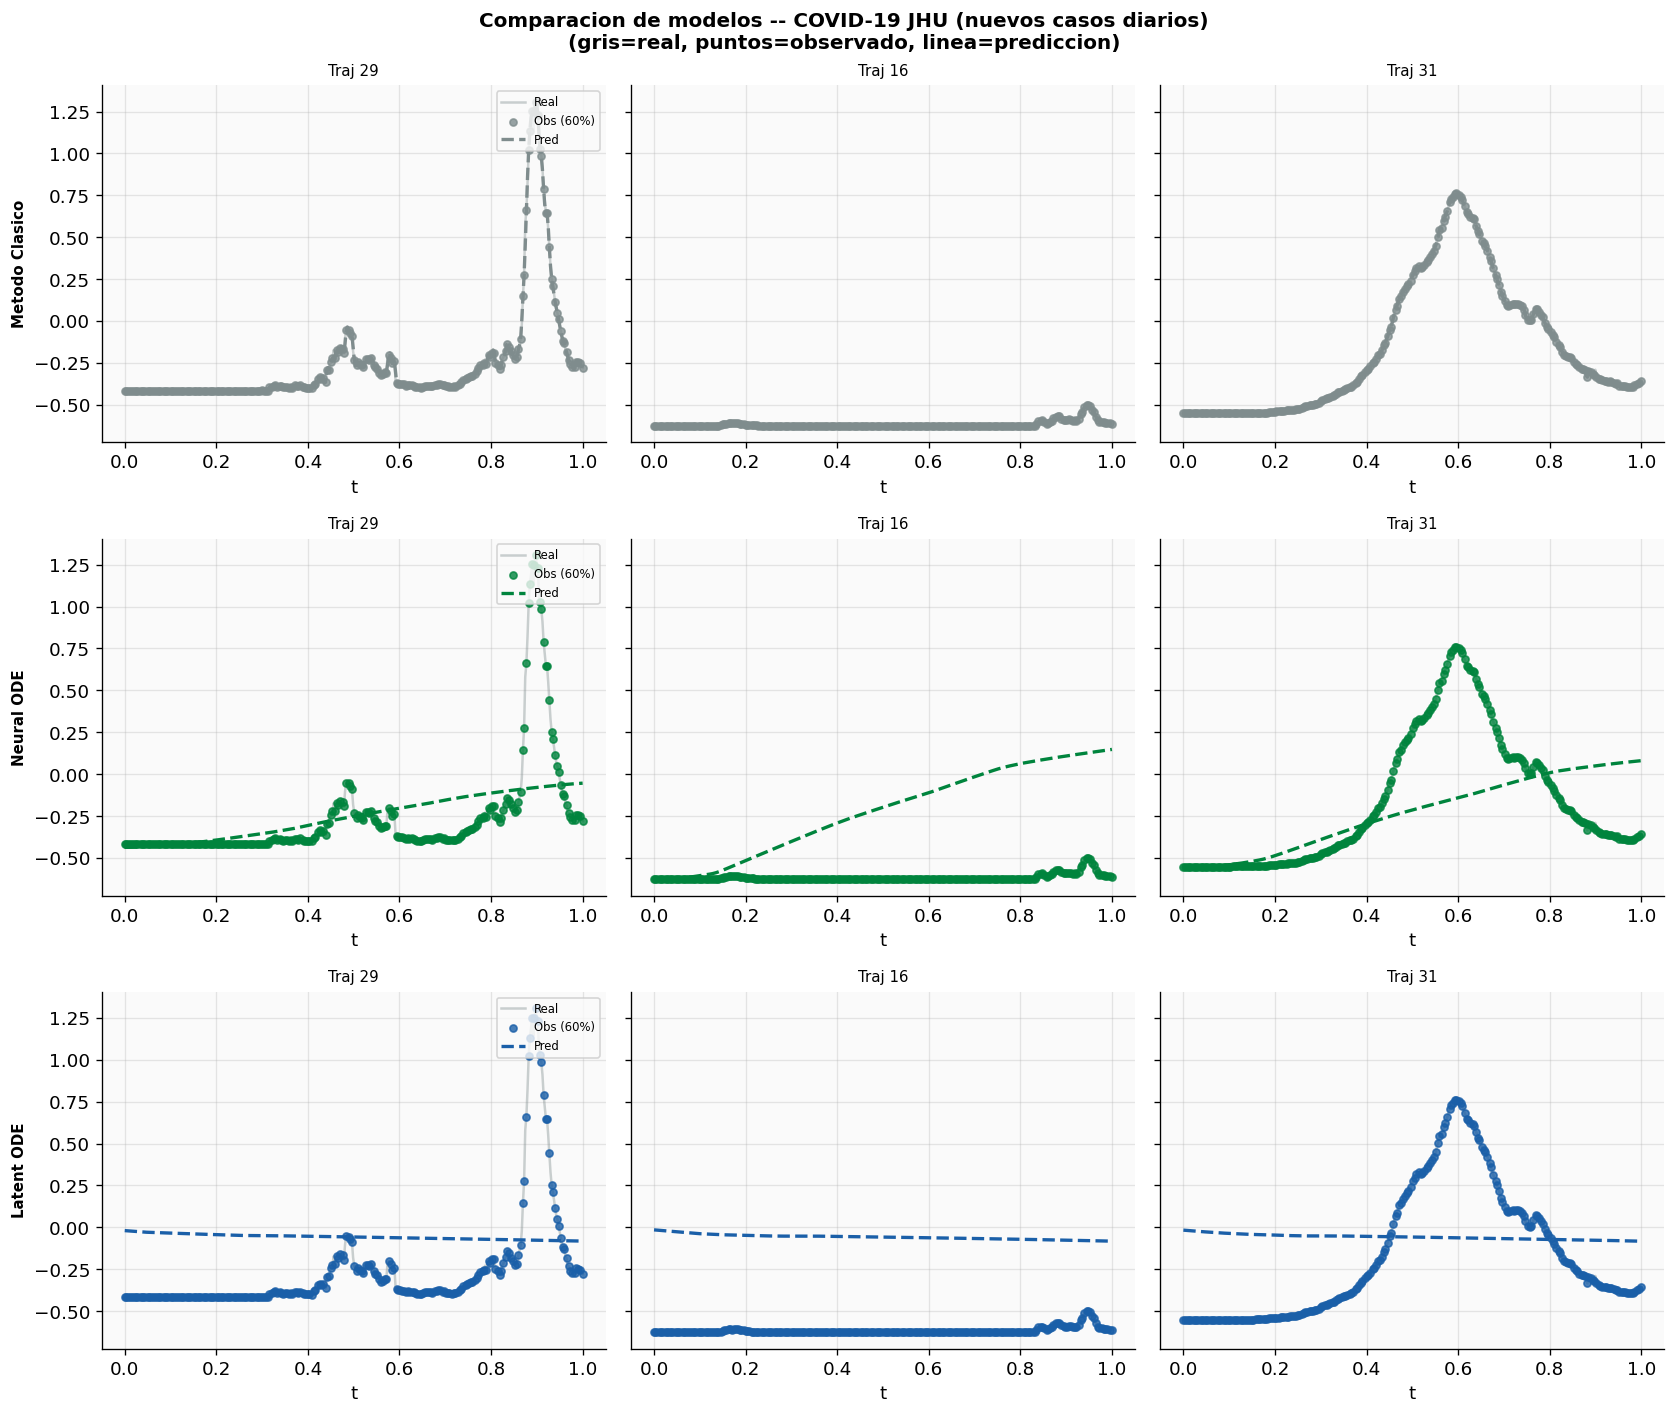

Guardada: fig_02_comparacion.png


In [ ]:
# Visualizacion comparativa
frac_viz = 0.6
times    = datos["tiempos"]
n_obs    = max(2, int(len(times) * frac_viz))
idx_obs  = np.linspace(0, len(times)-1, n_obs, dtype=int)
X_test   = datos["test"]
n_ej     = min(3, len(X_test))
idx_ej   = np.random.choice(len(X_test), n_ej, replace=False)

fig, axes = plt.subplots(len(MODELOS), n_ej,
                          figsize=(14, 4 * len(MODELOS)), sharey="row")

for row, M in enumerate(MODELOS):
    X_obs_batch = X_test[idx_ej][:, idx_obs, :]
    pred = M.predict(X_obs_batch, times[idx_obs], times)

    for col in range(n_ej):
        ax = axes[row, col]
        gt = X_test[idx_ej[col]]

        # Ground truth
        for d in range(DIM_OBS):
            ax.plot(times, gt[:, d], color=GRIS, lw=1.5, alpha=0.4,
                    label="Real" if d == 0 else None)

        # Observado
        ax.scatter(times[idx_obs], gt[idx_obs, 0], s=18,
                   color=M.color, zorder=4, alpha=0.8,
                   label=f"Obs ({int(frac_viz*100)}%)" if col == 0 else None)

        # Prediccion
        for d in range(DIM_OBS):
            ax.plot(times, pred[col, :, d], color=M.color, lw=2,
                    linestyle="--",
                    label="Pred" if (d == 0 and col == 0) else None)

        ax.set_xlabel("t")
        if col == 0:
            ax.set_ylabel(M.nombre, fontweight="bold", fontsize=9)
            ax.legend(fontsize=7, loc="upper right")
        ax.set_title(f"Traj {idx_ej[col]+1}", fontsize=9)

plt.suptitle(f"Comparacion de modelos -- {NOMBRE_DATASET}\n"
             f"(gris=real, puntos=observado, linea=prediccion)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_02_comparacion.png", dpi=120, bbox_inches="tight")
plt.show()
print("Guardada: fig_02_comparacion.png")


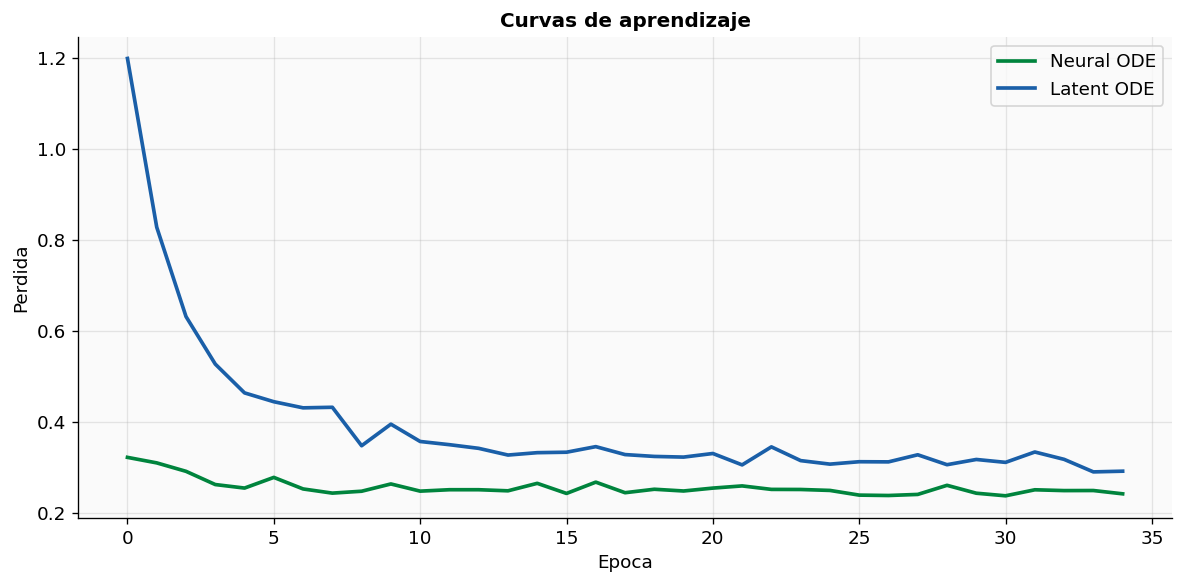

Guardada: fig_03_curvas.png


In [ ]:
# Curvas de aprendizaje
fig, ax = plt.subplots(figsize=(10, 5))
for M in [M_NODE, M_LATENT]:
    if M.historia:
        ax.plot(M.historia, color=M.color, lw=2.2, label=M.nombre)
ax.set_xlabel("Epoca"); ax.set_ylabel("Perdida")
ax.set_title("Curvas de aprendizaje", fontsize=12, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("fig_03_curvas.png", dpi=120, bbox_inches="tight")
plt.show()
print("Guardada: fig_03_curvas.png")


---
## SECCION 6: Exportar reporte y README


In [ ]:
# ============================================================
# Generar reporte .docx
# ============================================================

def generar_docx(datos, modelos, resultados, config, nombres_pareja):
    doc = Document()
    doc.styles["Normal"].font.name = "Calibri"
    doc.styles["Normal"].font.size = Pt(11)

    doc.add_heading("Neural ODEs sobre Datos Biologicos", 0)
    doc.add_paragraph(
        f"Analisis Numerico | Universidad Nacional de Colombia\n"
        f"Prof. Carlos Manuel Orrego Franco\n"
        f"Fecha: {datetime.now().strftime('%d de %B de %Y')}\n"
        f"Integrantes: {chr(44).join(nombres_pareja)}\n"
        f"Dataset: {datos['nombre']}"
    )
    doc.add_page_break()

    doc.add_heading("1. Descripcion del dataset", 1)
    traj = datos["trayectorias"]
    doc.add_paragraph(
        f"Dataset: {datos['nombre']}\n"
        f"Trayectorias: {traj.shape[0]}\n"
        f"Pasos de tiempo: {traj.shape[1]}\n"
        f"Dimensiones: {traj.shape[2]}\n"
        f"Variables: {chr(44).join(datos['variables'])}\n"
        f"Rango: [{traj.min():.3f}, {traj.max():.3f}]"
    )
    doc.add_paragraph("[Completen aqui el analisis exploratorio]")

    doc.add_heading("2. Hiperparametros elegidos y justificacion", 1)
    for k, v in config.items():
        if k != "fracciones_obs":
            doc.add_paragraph(f"- {k}: {v}")
    doc.add_paragraph("[Justifiquen cada eleccion]")

    doc.add_heading("3. Tabla de resultados RMSE", 1)
    fracs = config["fracciones_obs"]
    n_cols = 1 + len(fracs) * 2 + 2
    tabla  = doc.add_table(rows=1 + len(modelos), cols=n_cols)
    tabla.style = "Table Grid"
    hdr = tabla.rows[0].cells
    hdr[0].text = "Modelo"
    ci = 1
    for f in fracs:
        hdr[ci].text   = f"{int(f*100)}% rec"
        hdr[ci+1].text = f"{int(f*100)}% ext"
        ci += 2
    hdr[-2].text = "Params"
    hdr[-1].text = "Tiempo"
    for ri, M in enumerate(modelos):
        fila = tabla.rows[ri+1].cells
        fila[0].text = M.nombre
        ci = 1
        for f in fracs:
            r = resultados[f][M.nombre]
            fila[ci].text   = f"{r['rmse_rec']:.4f}"
            fila[ci+1].text = f"{r['rmse_ext']:.4f}"
            ci += 2
        rf = resultados[fracs[-1]][M.nombre]
        fila[-2].text = f"{rf['params']:,}"
        fila[-1].text = f"{rf['tiempo']:.1f}s"

    doc.add_heading("4. Figuras", 1)
    for fp, cap in [
        ("fig_01_exploracion.png", "Figura 1: Exploracion del dataset"),
        ("fig_02_comparacion.png", "Figura 2: Comparacion de modelos (60% obs.)"),
        ("fig_03_curvas.png",      "Figura 3: Curvas de aprendizaje"),
    ]:
        if os.path.exists(fp):
            doc.add_picture(fp, width=Inches(5.5))
            doc.add_paragraph(cap)

    doc.add_heading("5. Respuestas a las preguntas de analisis", 1)
    for pid, preg in [
        ("P1", "Con que porcentaje de observaciones empieza a ganar la Neural ODE?"),
        ("P2", "Por que el encoder RNN corre en orden inverso al tiempo?"),
        ("P3", "Hubo algun resultado sorpresivo? Por que?"),
        ("P4", "En que tipo de problema NO recomendarian una Neural ODE?"),
    ]:
        doc.add_paragraph(f"{pid}: {preg}", style="List Bullet")
        doc.add_paragraph("[Respuesta aqui]")

    doc.add_heading("6. Conclusiones", 1)
    doc.add_paragraph("[Conclusiones del grupo aqui]")

    nombre_archivo = "informe_neural_odes.docx"
    doc.save(nombre_archivo)
    print(f"Reporte guardado: {nombre_archivo}")
    try:
        from google.colab import files
        files.download(nombre_archivo)
    except ImportError:
        print(f"Descargue manualmente: {nombre_archivo}")


# EJECUTAR -- completar con sus nombres:
nombres_pareja = ["Tomas Otero Lopez", "Juan Esteban Toro Soto"]
generar_docx(datos, MODELOS, RESULTADOS, CONFIG, nombres_pareja)
print("Celda lista. Defina nombres_pareja y ejecute generar_docx().")


Reporte guardado: informe_neural_odes.docx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Celda lista. Defina nombres_pareja y ejecute generar_docx().


In [ ]:
# ============================================================
# Generar README.md automatico para GitHub
# ============================================================

def generar_readme(datos, modelos, resultados, config, nombres_pareja):
    fracs = config["fracciones_obs"]
    fref  = fracs[-1]
    lineas = [
        "# Neural ODEs sobre Datos Biologicos\n",
        "**Analisis Numerico | Universidad Nacional de Colombia**  \n",
        "Prof. Carlos Manuel Orrego Franco  \n",
        f"Generado: {datetime.now().strftime('%Y-%m-%d')}  \n",
        "\n---\n\n## Integrantes\n",
    ] + [f"- {n}\n" for n in nombres_pareja] + [
        f"\n## Dataset\n**{datos['nombre']}**  \n",
        f"- Trayectorias: {datos['trayectorias'].shape[0]}  \n",
        f"- Pasos de tiempo: {datos['trayectorias'].shape[1]}  \n",
        f"- Variables: {chr(44).join(datos['variables'])}  \n",
        "\n## Resultados (100% de observaciones)\n",
        "| Modelo | RMSE Rec | RMSE Ext | Params | Tiempo |\n",
        "|--------|----------|----------|--------|--------|\n",
    ] + [
        f"| {M.nombre} "
        f"| {resultados[fref][M.nombre]['rmse_rec']:.4f} "
        f"| {resultados[fref][M.nombre]['rmse_ext']:.4f} "
        f"| {resultados[fref][M.nombre]['params']:,} "
        f"| {resultados[fref][M.nombre]['tiempo']:.1f}s |\n"
        for M in modelos
    ] + [
        "\n## Reproducir\n",
        "```bash\n",
        "# Abrir A_notebook_base.ipynb en Google Colab\n",
        "# Ejecutar todas las celdas en orden desde la Seccion 1\n",
        "```\n",
        "\n## Estructura\n```\n",
        "notebooks/   <- NB01-NB07 + A_notebook_base.ipynb\n",
        "informe/     <- informe.tex + informe.pdf\n",
        "evidencia_ia/ <- capturas del chat con la IA\n",
        "README.md\n```\n",
    ]
    with open("README.md", "w", encoding="utf-8") as fh:
        fh.writelines(lineas)
    print("README.md generado. Copie a la raiz del repositorio.")


# EJECUTAR:
nombres_pareja = ["Tomas Otero Lopez", "Juan Esteban Toro Soto"]
generar_readme(datos, MODELOS, RESULTADOS, CONFIG, nombres_pareja)
print("Celda lista. Defina nombres_pareja y ejecute generar_readme().")


README.md generado. Copie a la raiz del repositorio.
Celda lista. Defina nombres_pareja y ejecute generar_readme().
